# Лабораторная работа №4

В этой лабораторной работе мы изученим линейные модели, SVM и деревья решений.

In [54]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from scipy.optimize import fmin_tnc
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC, NuSVC, LinearSVC, OneClassSVM, SVR, NuSVR, LinearSVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
import graphviz
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

## Задание

* Выберите набор данных (датасет) для решения задачи классификации или регрессии.
* В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
* С использованием метода train_test_split разделите выборку на обучающую и тестовую.
* Обучите следующие модели:
  - одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);
  - SVM;
  - дерево решений.
* Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.
* Постройте график, показывающий важность признаков в дереве решений.
* Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.

## Датасет

Для лабораторной работы выберем датасет распознания типа стекла: [ссылка](https://archive.ics.uci.edu/dataset/42/glass+identification). Перед нами задача классификации - по химическому составу определить, какого рода стекло перед нами.

Для удобства работы файл с данными отредактирован, чтобы первая строка содержала заголовки столбцов.

In [3]:
data = pd.read_csv('data/glass_identification/glass.csv', sep=",")

# Отбросим признак Id_number - он модели будет только мешать.
data = data.drop('Id_number', axis=1)

In [4]:
# Форма датасета

data.shape

(214, 10)

In [5]:
# Статистика по датасету

data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [6]:
# Первые 5 строк

data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


В датасете нет пропусков. Для признака RI (показатель преломления) может потребоваться масштабирование.

Теперь выделим целевой признак в отдельный датафрейм.

In [7]:
target = data['Type_of_glass']
data = data.drop('Type_of_glass', axis=1)

data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


## Разбиение датасета

Разобьем данные на две выборки: обучающую и тестовую. Пропорция: ~1/5 - тестовые данные, ~4/5 - обучающие.

In [8]:
# Разделение выборки на обучающую и тестовую
# Стратификация используется для сохранения распределения
glass_X_train, glass_X_test, glass_y_train, glass_y_test = train_test_split(
    data, target, test_size=0.2, random_state=1, stratify=target)

## Логистическая регрессия

Теперь на базе данных можно обучать разные модели. Начнем с модели логистической регрессии. Sklearn поддерживает использование такой модели в задаче многоклассовой классификации, так что выбор датасета не является препятствием.

In [16]:
# Подготовка данных: для этой модели (и для SVM) потребуется масштабирование

from sklearn.preprocessing import StandardScaler

# Создаем scaler на основе обучающей выборки
scaler = StandardScaler()
glass_X_train_scaled = scaler.fit_transform(glass_X_train)
glass_X_test_scaled = scaler.transform(glass_X_test)  # Используем тот же scaler

In [17]:
logreg = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=1
)
logreg.fit(glass_X_train_scaled, glass_y_train)
y_pred_logreg = logreg.predict(glass_X_test_scaled)

Для оценки качества моделей используем две метрики: __accuracy__ (доля верных предсказаний) и __F1-мера__ (среднее гармоническое между precision и recall для каждого класса, взвешенное по количеству объектов в каждом классе).

In [25]:
# Метрики оценки качества модели
accuracy_logreg = accuracy_score(glass_y_test, y_pred_logreg)
f1_weighted_logreg = f1_score(glass_y_test, y_pred_logreg, average='weighted')
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"F1-weighted: {f1_weighted_logreg:.4f}")

Accuracy: 0.7209
F1-weighted: 0.6969


## SVM

Теперь построим модель SVM. Данные отмасштабированы в предыдущем пункте.

In [26]:
svm = SVC(random_state=1)
svm.fit(glass_X_train_scaled, glass_y_train)
y_pred_svm = svm.predict(glass_X_test_scaled)

In [27]:
# Метрики оценки качества модели
accuracy_svm = accuracy_score(glass_y_test, y_pred_svm)
f1_weighted_svm = f1_score(glass_y_test, y_pred_svm, average='weighted')
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"F1-weighted: {f1_weighted_svm:.4f}")

Accuracy: 0.6744
F1-weighted: 0.6544


## Дерево решений

Наконец, построим дерево решений. Для этой модели масштабирование данных не требуется.

In [29]:
tree = DecisionTreeClassifier(random_state=1)
tree.fit(glass_X_train, glass_y_train)
y_pred_tree = tree.predict(glass_X_test)

In [30]:
# Метрики оценки качества модели
accuracy_tree = accuracy_score(glass_y_test, y_pred_tree)
f1_weighted_tree = f1_score(glass_y_test, y_pred_tree, average='weighted')
print(f"Accuracy: {accuracy_tree:.4f}")
print(f"F1-weighted: {f1_weighted_tree:.4f}")

Accuracy: 0.7907
F1-weighted: 0.7963


## Сравнение качества полученных моделей

У нас уже есть оценки качества всех трех построенных моделей. Сведем их в таблицу.

In [49]:
print("=" * 80)
print(" " * 12 + "Лог. регр. |  SVM   | Дер. реш.")
print(f"Accuracy    {accuracy_logreg:.4f}     | {accuracy_svm:.4f} | {accuracy_tree:.4f}")
print(f"F1-weighted {f1_weighted_logreg:.4f}     | {f1_weighted_svm:.4f} | {f1_weighted_tree:.4f}")
print("=" * 80)

            Лог. регр. |  SVM   | Дер. реш.
Accuracy    0.7209     | 0.6744 | 0.7907
F1-weighted 0.6969     | 0.6544 | 0.7963


Таким образом, для данного датасета и в данной конфигурации моделей хуже всего по выбранным метрикам показывает себя дерево решений, а хуже всего - SVM. Логистическая регрессия по качеству расположилась ровно между двумя другими моделями.

## Важность признаков в дереве решения

Построим график, показывающий важность признаков в дереве решений.

In [51]:
# Опишем функцию построения графика
from operator import itemgetter

def draw_feature_importances(tree_model, X_dataset, figsize=(18,5)):
    """
    Вывод важности признаков в виде графика
    """
    # Сортировка значений важности признаков по убыванию
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse = True)
    # Названия признаков
    labels = [x for x,_ in sorted_list]
    # Важности признаков
    data = [x for _,x in sorted_list]
    # Вывод графика
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    # Вывод значений
    for a,b in zip(ind, data):
        plt.text(a-0.05, b+0.01, str(round(b,3)))
    plt.show()
    return labels, data

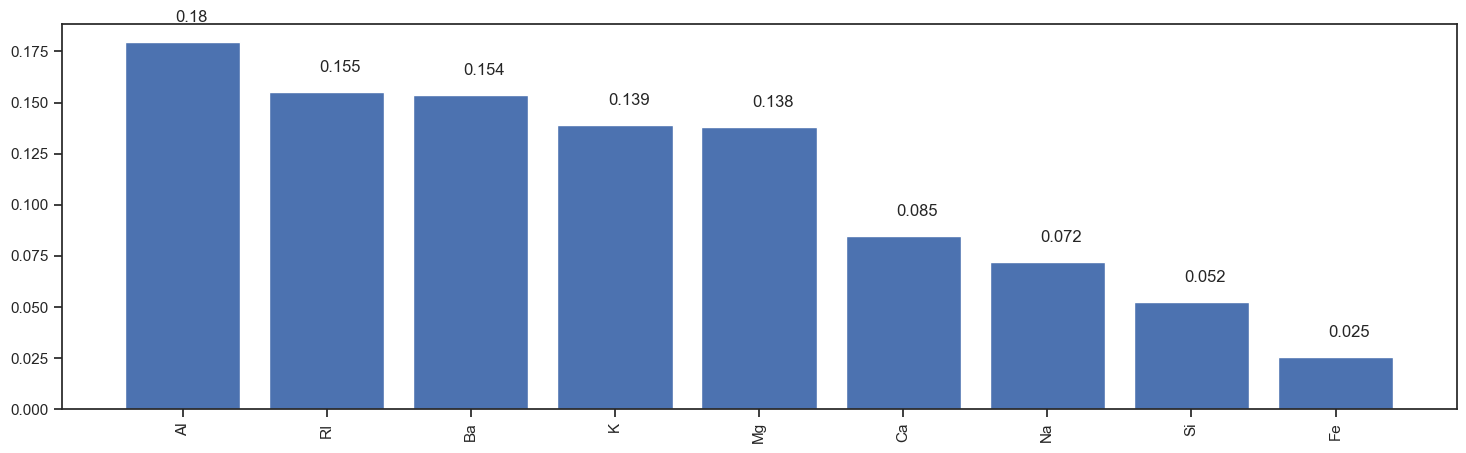

In [52]:
glass_tree_cl_fl, glass_tree_cl_fd = draw_feature_importances(tree, data)

## Визуализация дерева решений

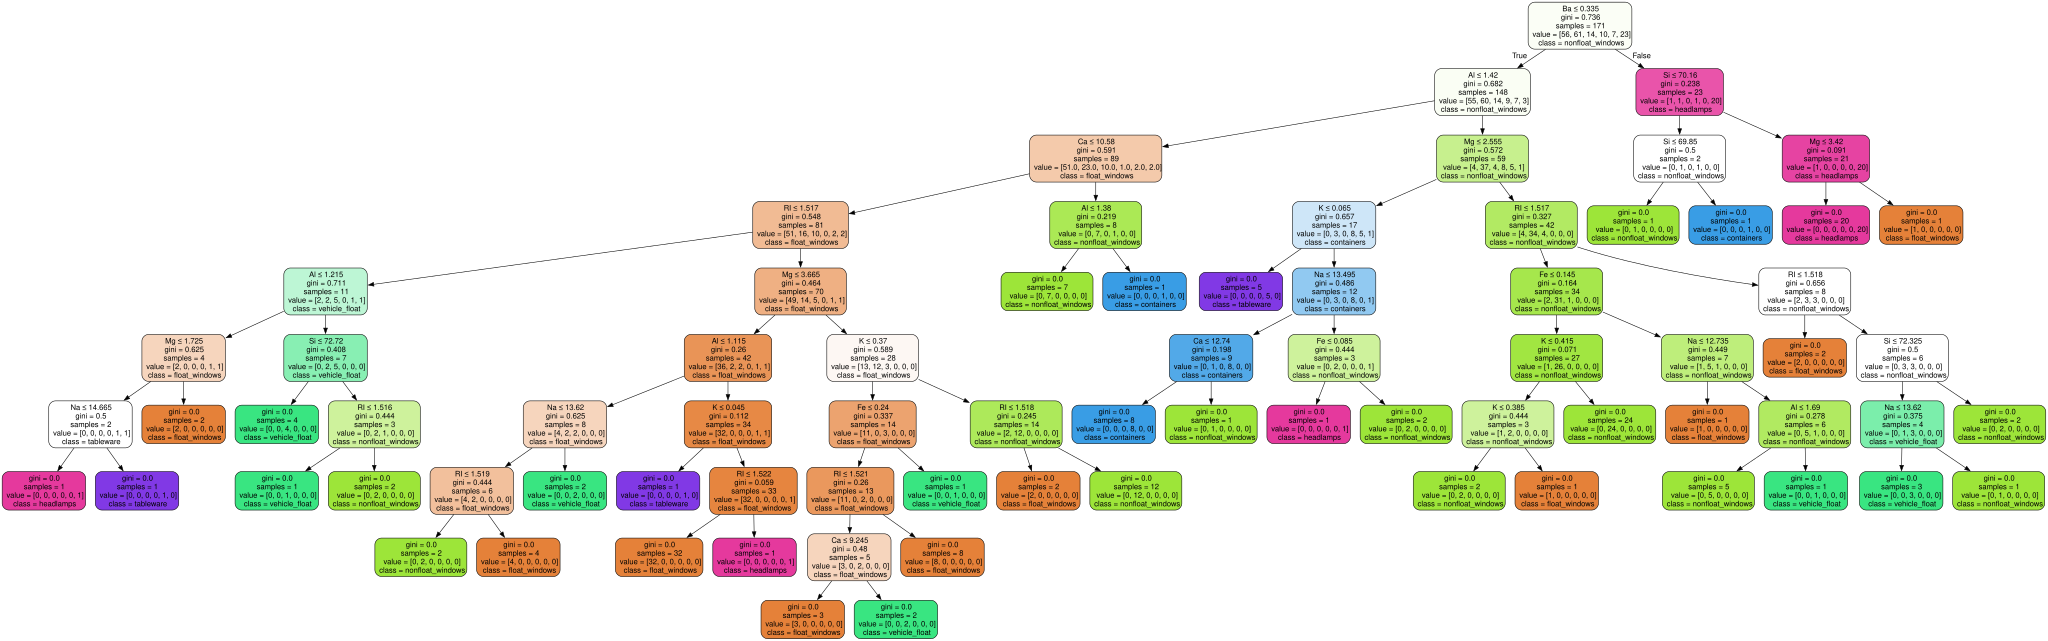

In [58]:
feature_names = data.columns.tolist()

class_labels = sorted(target.unique())
class_dict = {
    1: 'float_windows',
    2: 'nonfloat_windows',
    3: 'vehicle_float',
    5: 'containers',
    6: 'tableware',
    7: 'headlamps'
}
class_names = [class_dict[i] for i in class_labels]

dot_data = export_graphviz(
    tree,
    out_file=None,
    feature_names=feature_names,           
    class_names=class_names,               
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=15
)

graph = graphviz.Source(dot_data)
graph

## Вывод

Сравнение моделей показало, что дерево решений превосходит логистическую регрессию и SVM. Это может указывать на наличие нелинейных пороговых зависимостей в данных, которые дерево эффективно выявляет. Более низкий F1-score у логистической регрессии и SVM говорит о том, что эти модели хуже справляются с редкими классами.